In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-book-foundations.6j_z9po4/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-book-foundations.6j_z9po4/venv", "python": "3.12.14", "torch_cuda_build": null}


# How loss trains attention: routing, content, and saturation

Chapter 4 · Session 2. Companion to sections 4.5–4.8 of the [chapter](../../book/chapters/04-attention-and-the-causal-information-boundary.md).

Follow the forward notebook first or read its solutions. This session uses a tiny fixed next-token classification head, one observed target, and no optimizer steps. You may read the complete solutions now and return to the optional coding exercises later. Tests verify the reference path; they do not assess your understanding.

In [2]:
from pathlib import Path
import sys
import math
import torch
import torch.nn.functional as F
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/dongxi_llms/attention_evidence.py').exists())
if str(root / 'src') not in sys.path: sys.path.insert(0, str(root / 'src'))
from dongxi_llms.causal_attention_lab import attention_trace, teaching_inputs
from dongxi_llms.attention_evidence import gradient_evidence, scaling_evidence, cache_fixture, full_stack, decode_step, cache_evidence
torch.set_printoptions(precision=5, sci_mode=False)
print('PyTorch', torch.__version__, '| CPU float64')

PyTorch 2.14.1+cpu | CPU float64


### Prediction

## 1. Prediction: does loss supervise the attention map?

A single cross-entropy target is attached to position 2 (zero-based). Does loss update only V, or Q and K as well? Can earlier input rows receive gradients even though they have no direct target? Can row 3?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [3]:
prediction_gradient_paths = ""

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [4]:
x, wq, wk, wv = [t.clone().requires_grad_() for t in teaching_inputs()]
q, k, v = x @ wq, x @ wk, x @ wv
trace = attention_trace(q, k, v)
a, o = trace['weights'], trace['output']
for t in (q, k, v, a, o, trace['scaled']): t.retain_grad()
head = x.new_tensor([[1., -.5, .2], [-.3, .7, 1.]])
logits = o[2] @ head
loss = F.cross_entropy(logits[None], torch.tensor([1]))
loss.backward()
print('loss:', loss.item(), '| logits:', logits.detach())
print('input gradients by position:\n', x.grad)
assert x.grad[3].count_nonzero() == 0
assert x.grad[:2].norm() > 0

loss: 2.030520960114874 | logits: tensor([1.05244, 0.30070, 1.80419], dtype=torch.float64)
input gradients by position:
 tensor([[ 0.51165,  0.04886,  0.42968],
        [ 0.18441, -0.27838, -0.22481],
        [ 1.19368, -0.07216,  1.05446],
        [ 0.00000,  0.00000,  0.00000]], dtype=torch.float64)


### Reference explanation

### Reference solution

Q/K determine routing and V determines transmitted content; both routes can affect the prediction. Earlier input rows can receive credit through the chosen position's keys and values. Row 3 cannot affect position 2, so its input gradient is zero for this isolated loss. Shared parameters still update; that does not mean row 3 supplied information.

Run the following transparent forward/backward pass. The class label supplies no target attention matrix.


### Prediction

## 2. Implementation: derive the backward pass

Let G_O be the incoming derivative. Fill the expressions for G_V, G_A, and G_R. All tensors use rows for positions; R is the masked scaled score matrix. Treat the mask as fixed. Then extend the derivation through Q/K and the projection matrices.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [5]:
def my_backward(a, v, go):
    gv = ...
    ga = ...
    gr = ...
    return gv, ga, gr
run_my_backward = False
if run_my_backward:
    mine = my_backward(a.detach(), v.detach(), o.grad)

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [6]:
go = o.grad
manual_gv = a.detach().T @ go
manual_ga = go @ v.detach().T
manual_gr = a.detach() * (manual_ga - (manual_ga * a.detach()).sum(-1, keepdim=True))
for expected, actual in [(manual_gv, v.grad), (manual_ga, a.grad), (manual_gr, trace['scaled'].grad)]:
    torch.testing.assert_close(expected, actual, atol=1e-12, rtol=1e-12)
if run_my_backward:
    for actual, expected in zip(mine, [manual_gv, manual_ga, manual_gr]):
        torch.testing.assert_close(actual, expected)
report = gradient_evidence()
print('Manual versus autograd errors:', report['manual_errors'])
print('Central-difference max error:', report['finite_difference_error'])
assert max(report['manual_errors'].values()) < 1e-12
assert report['finite_difference_error'] < 1e-7
assert report['forbidden_score_gradient'] == 0

Manual versus autograd errors: {'Q': 9.71445146547012e-17, 'K': 8.326672684688674e-17, 'V': 0.0, 'A': 0.0, 'scores': 1.1102230246251565e-16, 'W_Q': 9.71445146547012e-17, 'W_K': 1.1102230246251565e-16, 'W_V': 0.0, 'X': 2.220446049250313e-16}
Central-difference max error: 1.8291579362283983e-10


### Reference explanation

### Reference solution

G_V=AᵀG_O and G_A=G_OVᵀ. Each row's score gradient is A multiplied elementwise by its incoming derivative minus its A-weighted average. The subtraction reflects competition within a row.

Next, G_Q=G_R K/√d_k and G_K=G_RᵀQ/√d_k; projection gradients are Xᵀ times the projected-vector gradient. X receives all three paths added together. The fixed forbidden entries have zero score gradient.


### Prediction

## 3. Intervention: freeze a route without changing the forward answer

Predict what `a.detach() @ v` and `a @ v.detach()` do. Does detaching change the loss value? Which projection parameters lose their gradient path?

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [7]:
prediction_detach = ""

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [8]:
for choice in [None, 'routing', 'values']:
    r = gradient_evidence(choice)
    print('Detach:', choice, '| loss:', r['loss'], '| gradient norms:', r['gradient_norms'])

Detach: None | loss: 2.030520960114874 | gradient norms: {'X': 1.7756089292990331, 'W_Q': 0.35173598561995556, 'W_K': 0.3517359856199555, 'W_V': 0.8898004801031433}
Detach: routing | loss: 2.030520960114874 | gradient norms: {'X': 1.1760236846219732, 'W_Q': None, 'W_K': None, 'W_V': 0.8898004801031433}
Detach: values | loss: 2.030520960114874 | gradient norms: {'X': 0.9175792154672036, 'W_Q': 0.35173598561995556, 'W_K': 0.3517359856199555, 'W_V': None}


### Reference explanation

### Reference solution

Detach preserves the tensor's forward value and removes its backward connection. Detaching A prevents gradients reaching W_Q and W_K in this isolated graph; W_V still receives gradients. Detaching V removes W_V's path while routing can still learn from fixed values. These statements assume independent projection parameters and no other loss paths.


### Prediction

## 4. Prediction and experiment: why divide by √d_k?

Under independent zero-mean unit-variance coordinates, Var(q·k)=d_k. Without scaling, wider heads create larger score gaps even before learning. Predict how this affects entropy and local sensitivity.

Entropy is −Σ a log a. The softmax Jacobian's trace is 1−Σ a². Near a one-hot row this trace approaches zero. This is a sensitivity measure, not a gradient of a language-model loss.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [9]:
prediction_scaling = ""

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [10]:
rows = scaling_evidence()
for row in rows:
    print({key: round(value, 5) if isinstance(value, float) else value for key, value in row.items()})
# Optional: change widths, seed, rows, or keys in scaling_evidence(...).
# Compare paired scaled/unscaled scores at each width, not unrelated draws.

{'width': 8, 'raw_std': 2.84406, 'scaled_std': 1.00553, 'raw_entropy': 1.24229, 'raw_jacobian_trace': 0.5483, 'scaled_entropy': 2.35528, 'scaled_jacobian_trace': 0.86461}
{'width': 64, 'raw_std': 7.98888, 'scaled_std': 0.99861, 'raw_entropy': 0.42197, 'raw_jacobian_trace': 0.22472, 'scaled_entropy': 2.36165, 'scaled_jacobian_trace': 0.86903}
{'width': 512, 'raw_std': 22.28492, 'scaled_std': 0.98486, 'raw_entropy': 0.11479, 'raw_jacobian_trace': 0.06529, 'scaled_entropy': 2.35443, 'scaled_jacobian_trace': 0.86601}


### Reference explanation

### Reference solution

Unscaled score spread grows approximately as √d_k under these assumptions. Scaling controls that spread and usually avoids near-one-hot initial rows. The exact statistics vary with the random draws. Learned queries/keys need not satisfy the IID assumptions.

This does not contradict Chapter 3's strong p−q correction for confidently wrong vocabulary predictions. That result uses the special combination of softmax and cross-entropy. Attention receives a derivative through a value mixture, so the same cancellation is not generally present.


### Prediction

## 5. Interpretation: can different attention maps yield the same result?

If the third value is the average of the first two, must changing attention weights change the output? Predict before running.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [11]:
prediction_explanation = ""

### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [12]:
values = torch.tensor([[2., 0.], [0., 2.], [1., 1.]], dtype=torch.float64)
weights_a = torch.tensor([.4, .4, .2], dtype=values.dtype)
weights_b = torch.tensor([.1, .1, .8], dtype=values.dtype)
print(weights_a @ values, weights_b @ values)
torch.testing.assert_close(weights_a @ values, weights_b @ values)

tensor([1., 1.], dtype=torch.float64) tensor([1., 1.], dtype=torch.float64)


### Reference explanation

### Reference solution

Different distributions can transport the same value mixture. Therefore attention weights alone do not even uniquely determine the head's contribution without V, much less explain the final model prediction.


### Prediction

## Evidence boundary

Write what the verified derivatives and interventions establish.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [13]:
my_evidence_boundary = ""

## Visual extension — backward routes and softmax saturation


### Prediction

Prediction: If routing is detached, which projection gradients disappear? If head width grows, how will unscaled score spread and attention entropy change?

Make your explanation before running the plot.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


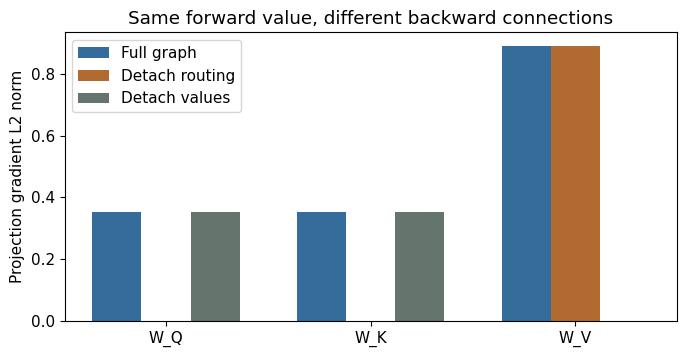

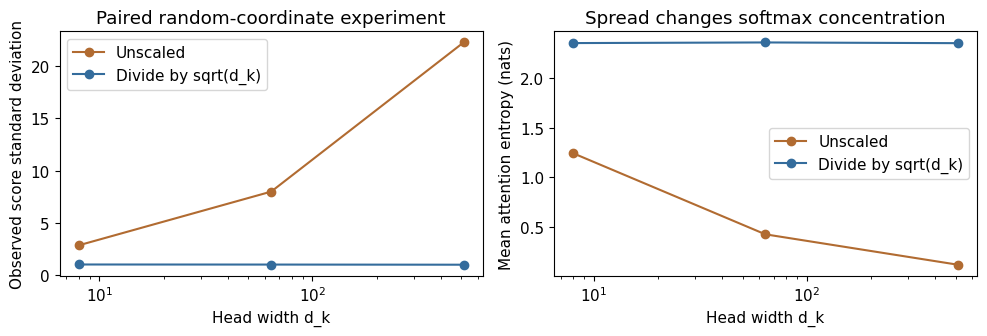

In [14]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white",
                     "font.family":"DejaVu Sans","font.size":11})
visual_routes=[None,"routing","values"]
visual_reports=[gradient_evidence(route) for route in visual_routes]
visual_names=["W_Q","W_K","W_V"]
visual_grid=np.array([[r["gradient_norms"][name] or 0. for name in visual_names] for r in visual_reports])
fig,ax=plt.subplots(figsize=(7,3.7))
for offset,index,label,color in [(-.24,0,"Full graph","#346c9c"),(0,1,"Detach routing","#b16b31"),(.24,2,"Detach values","#65746d")]:
    ax.bar(np.arange(3)+offset,visual_grid[index],width=.24,label=label,color=color)
ax.set(xticks=range(3),xticklabels=visual_names,ylabel="Projection gradient L2 norm",title="Same forward value, different backward connections")
ax.legend(); plt.tight_layout(); plt.show()
visual_scaling=scaling_evidence()
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
for prefix,label,color in [("raw","Unscaled","#b16b31"),("scaled","Divide by sqrt(d_k)","#346c9c")]:
    axes[0].plot([r["width"] for r in visual_scaling],[r[prefix+"_std"] for r in visual_scaling],"o-",label=label,color=color)
    axes[1].plot([r["width"] for r in visual_scaling],[r[prefix+"_entropy"] for r in visual_scaling],"o-",label=label,color=color)
axes[0].set(xlabel="Head width d_k",ylabel="Observed score standard deviation",xscale="log",title="Paired random-coordinate experiment")
axes[1].set(xlabel="Head width d_k",ylabel="Mean attention entropy (nats)",xscale="log",title="Spread changes softmax concentration")
axes[0].legend(); axes[1].legend(); plt.tight_layout(); plt.show()

### Reference explanation

### Reference solution

Analytical derivatives agree with autograd and finite differences for a fixed fixture. Controlled detach operations isolate two paths. An IID simulation illustrates the scaling argument. None of these establishes semantic roles for heads, trained-model capability, or GPU speed. The complete derivation and exercise answers are in the chapter and its [solutions](../../book/solutions/04-attention-and-the-causal-information-boundary.md).

### Reference explanation and reading guide

The first plot compares actual projection gradient norms while preserving the forward loss. The second figure uses paired IID coordinate simulations: dividing by sqrt(d_k) controls score spread and prevents the same width increase from driving attention toward low entropy. These simulations are mechanism evidence, not learned head interpretations.

Saved reference preview (generated 2026-10-04):

![Visual extension — backward routes and softmax saturation](../figures/chapter-04/day-04-02_attention_gradients_and_failures-01.png)

The preview is fixed; rerun the reference cell above to regenerate figures from the current reference tensors. Matplotlib is required for this optional visual extension.
